# Experiment 3: Loss Function Comparison for Jaguar Re-Identification

**Research Question:** Which loss function when used with an identical frozen MegaDescriptor-L-384 backbone, projection head, and training protocol yields the highest identity-balanced mAP for jaguar re-identification?

## Overview

1. **Data Loading**: Stratified train/validation split ensuring all identities appear in both sets
2. **Embedding Extraction**: Pre-compute embeddings from frozen MegaDescriptor-L-384 (shared across all loss functions)
3. **Loss Function Comparison**: Train identical projection heads with 4 different loss functions
4. **Evaluation**: Identity-balanced mAP on validation set for each loss function
5. **Submission**: Generate submission using the best-performing loss function

## Loss Functions Compared 

| Loss Function | Type | Key Hyperparameters |
|---|---|---|
| **ArcFace** | Angular Margin | margin=0.5, scale=64 |
| **CosFace** | Cosine Margin | margin=0.35, scale=64 |
| **SubCenterArcFace** | Sub-center Angular Margin | margin=0.5, scale=64, K=3 |
| **Focal Loss** | Weighted Classification | gamma=2.0 |

## Controlled Variables (Same Across ALL Loss Functions)
- Backbone: **MegaDescriptor-L-384** (frozen, pre-computed embeddings)
- Projection head: Linear(1536 → 512 → 256), BatchNorm, ReLU, Dropout(0.3)
- Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
- Epochs: 50, Batch size: 32, Seed: 42
- Embedding dim: 256 (output of projection head — same for all)
- Evaluation: Identity-balanced mAP on fixed val split (val_split=0.2)

## 1. Setup and Configuration

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
import math
import wandb
from kaggle_secrets import UserSecretsClient

# Secrets
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]        = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

# Reproducibility seed
RANDOM_SEED = 42

def set_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")
print(f"Device: {device}")

Using CUDA GPU
Device: cuda


In [2]:
secret_value_1 = user_secrets.get_secret("wandb_api")
print(len(secret_value_1))

86


In [3]:
# Device configuration
print(f"Device: {device}")

Device: cuda


In [4]:
# Controlled variables: SAME for all loss functions
RANDOM_SEED = 42

LOSS_CONFIGS = [
    {
        "loss_name": "ArcFace",
        "loss_type": "arcface",
        "margin": 0.5,
        "scale": 64.0,
    },
    {
        "loss_name": "CosFace",
        "loss_type": "cosface",
        "margin": 0.35,
        "scale": 64.0,
    },
    {
        "loss_name": "SubCenterArcFace",
        "loss_type": "subcenter_arcface",
        "margin": 0.5,
        "scale": 64.0,
        "K": 3,
    },
    {
        "loss_name": "FocalLoss",
        "loss_type": "focal",
        "gamma": 2.0,
    },
]

config = {
    # Paths
    "data_dir": Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("checkpoints"),

    # Backbone (fixed)
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,

    # Shared model settings
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,

    # ArcFace defaults
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "focal_gamma": 2.0,

    # Training (same for all losses)
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "patience": 10,
    "val_split": 0.2,

    # Reproducibility
    "seed": RANDOM_SEED,
}

# Create checkpoint directory
config["checkpoint_dir"].mkdir(exist_ok=True)

print("Loss Function Comparison Configuration:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Hidden dim: {config['hidden_dim']}")
print(f"  Dropout: {config['dropout']}")
print(f"  Learning rate: {config['learning_rate']}")
print(f"  Epochs: {config['num_epochs']}")
print(f"\nLoss functions to compare:")
for lc in LOSS_CONFIGS:
    print(f"  - {lc['loss_name']} ({lc['loss_type']})")


Q3 Loss Function Comparison Configuration:
  Embedding dim: 256
  Hidden dim: 512
  Dropout: 0.3
  Learning rate: 0.0001
  Epochs: 50

Loss functions to compare:
  - ArcFace (arcface)
  - CosFace (cosface)
  - SubCenterArcFace (subcenter_arcface)
  - FocalLoss (focal)


In [5]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
# Initialize Weights and Biases for experiment tracking
# Loss Function Comparison - single run for entire experiment
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    config={
        # Experiment info
        "experiment": "loss-function-comparison",
        "losses_compared": ["ArcFace", "CosFace", "SubCenterArcFace", "FocalLoss"],
        "num_losses": 4,
        # Model architecture (same for all losses)
        "embedding_dim": config["embedding_dim"],
        "hidden_dim": config["hidden_dim"],
        "dropout": config["dropout"],
        # Training hyperparameters (same for all losses)
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "num_epochs": config["num_epochs"],
        "patience": config["patience"],
        "val_split": config["val_split"],
        "seed": config["seed"],
    },
    name="loss-comparison",
)
print("W&B initialized for Loss Function Comparison experiment")
print(f"  Project: {os.getenv('WANDB_PROJECT', 'jaguar-reid-iota')}")
print(f"  Run name: loss-comparison")
print(f"  Losses: ArcFace, CosFace, SubCenterArcFace, FocalLoss")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Dropout: {config['dropout']}")

W&B initialized for Q3 Loss Function Comparison experiment
  Project: jaguar-reid-iota
  Run name: loss-comparison-q3
  Losses: ArcFace, CosFace, SubCenterArcFace, FocalLoss
  Embedding dim: 256
  Dropout: 0.3


## 2. Load and Prepare Data

We load the training data from `train.csv` which contains image filenames and their corresponding jaguar identity labels. The key challenge is creating a proper train/validation split:

**Stratified Split**: We ensure every jaguar identity appears in both the training and validation sets. This is critical because:
1. The model must learn to recognize all individuals during training
2. Validation mAP should reflect performance across all identities
3. Identities with few images still need representation in both sets

In [7]:
# Load training data
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

# Analyze identity distribution
identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min images per identity: {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max images per identity: {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean images per identity: {identity_counts.mean():.1f}")

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min images per identity: 13 (Ipepo)
  Max images per identity: 183 (Marcela)
  Mean images per identity: 61.1


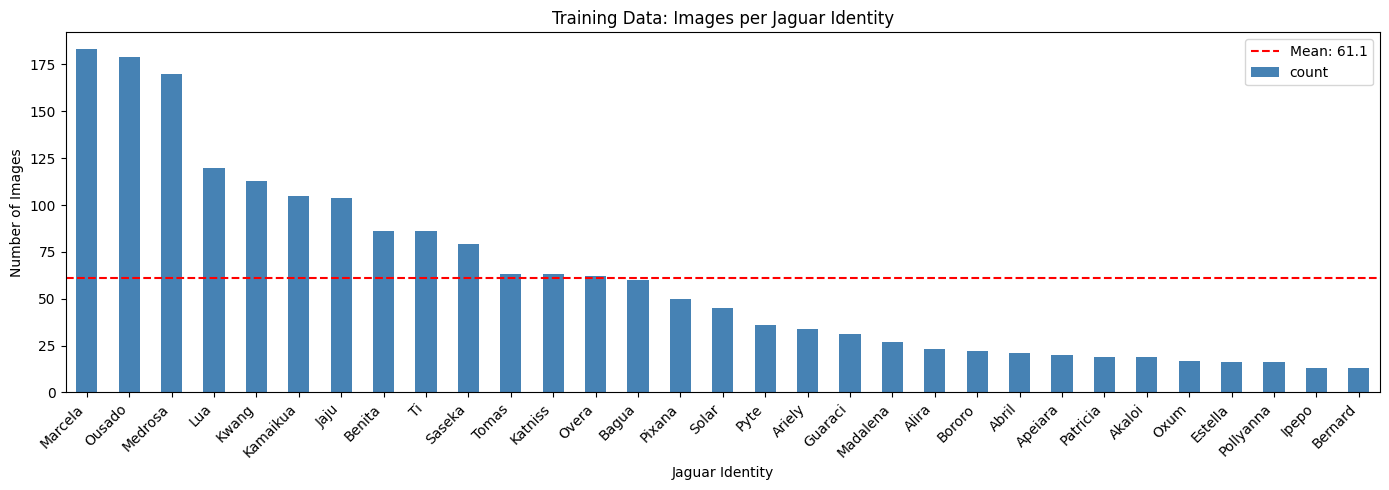

In [8]:
# Visualize identity distribution and log to W&B
fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Training Data: Images per Jaguar Identity')
ax.axhline(y=identity_counts.mean(), color='red', linestyle='--', label=f'Mean: {identity_counts.mean():.1f}')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Log to W&B
wandb.log({"identity_distribution_full": wandb.Image(fig)})
plt.show()

# Identify identities that may need careful handling (few samples)
min_samples_for_split = 2  # Need at least 2 to split
low_sample_identities = identity_counts[identity_counts < min_samples_for_split]

if len(low_sample_identities) > 0:   
    print(f"\nWarning: {len(low_sample_identities)} identities have fewer than {min_samples_for_split} images")

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


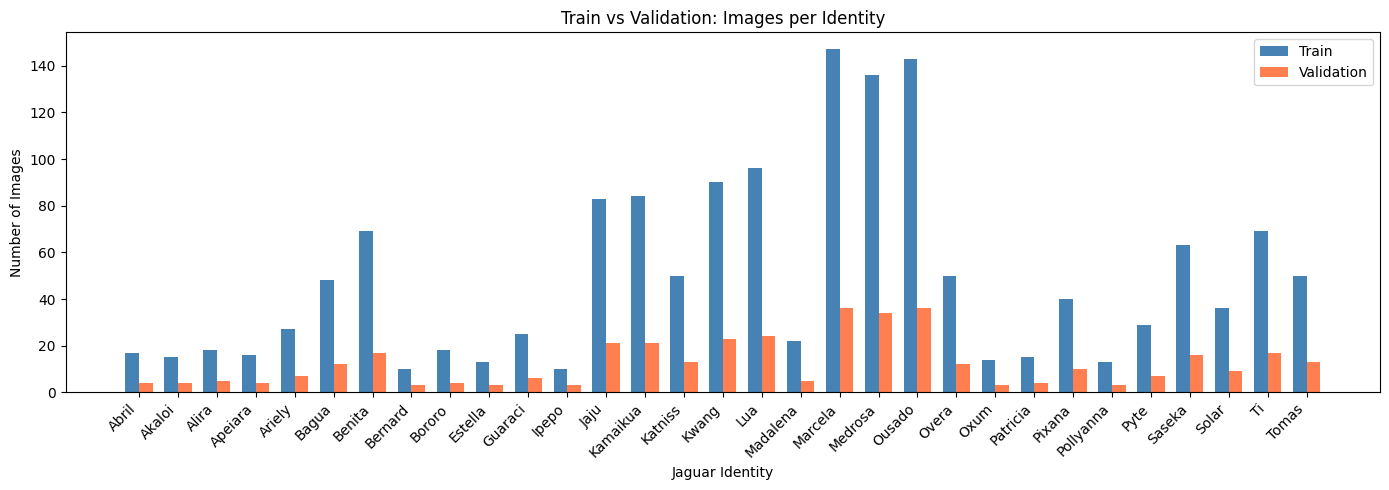


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [9]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## 3. Load MegaDescriptor Model

MegaDescriptor is a Vision Transformer (ViT-L/14) trained specifically for wildlife re-identification. It was trained on multiple species datasets and produces 1536-dimensional embeddings.

We use the `timm` library to load the pre-trained model from Hugging Face Hub.

Since all loss functions share the same backbone, we extract embeddings ONCE and reuse them.

In [10]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)

print(f"Model loaded successfully")
print(f"  Parameters: {sum(p.numel() for p in megadescriptor.parameters()):,}")

# Get the embedding dimension from the model
with torch.no_grad():
    dummy_input = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

Loading MegaDescriptor-L-384 model...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Model loaded successfully
  Parameters: 195,198,516
  Embedding dimension: 1536


In [11]:
# Define preprocessing pipeline
# MegaDescriptor expects 384x384 images normalized with ImageNet statistics
preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print("Preprocessing pipeline configured:")
print(f"  Resize to: {config['input_size']}x{config['input_size']}")
print(f"  Normalization: ImageNet statistics")

Preprocessing pipeline configured:
  Resize to: 384x384
  Normalization: ImageNet statistics


In [12]:
@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting embeddings"):
    """Extract embeddings for a list of image paths using MegaDescriptor."""
    model.eval()
    embeddings = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]
        
        # Load and preprocess batch
        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                # Use zero tensor as fallback
                batch_tensors.append(torch.zeros(3, config["input_size"], config["input_size"]))
        
        # Stack and move to device
        batch_tensor = torch.stack(batch_tensors).to(device)
        
        # Get embeddings
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)
    
    return np.vstack(embeddings)

print("Embedding extraction function defined")

Embedding extraction function defined


In [13]:
# Prepare image paths for train set
train_filenames = train_data["filename"].astype(str).tolist()
train_image_paths = [config["data_dir"] / "train/train" / fn for fn in train_filenames]

# Extract and cache train embeddings
cache_path = Path("/kaggle/working/embeddings")
cache_path.mkdir(parents=True, exist_ok=True)
train_cache = cache_path / "baseline_train_embeddings.npz"

if train_cache.exists():
    z = np.load(train_cache, allow_pickle=True)
    baseline_train_embeddings = z["embeddings"]
    print(f"Loaded cached train embeddings from {train_cache}")
else:
    print(f"Extracting baseline train embeddings for {len(train_image_paths)} images...")
    baseline_train_embeddings = extract_embeddings(
        megadescriptor, train_image_paths,
        batch_size=config["batch_size"], desc="Train embeddings"
    )
    np.savez_compressed(
        train_cache,
        embeddings=baseline_train_embeddings,
        filenames=np.array(train_filenames, dtype=object),
    )
    print(f"Saved train embeddings cache to {train_cache}")

print(f"Baseline train embeddings shape: {baseline_train_embeddings.shape}")


Extracting baseline train embeddings for 1516 images...


Train embeddings:   0%|          | 0/48 [00:00<?, ?it/s]

Saved train embeddings cache to /kaggle/working/embeddings/baseline_train_embeddings.npz
Baseline train embeddings shape: (1516, 1536)


## 4. Visualize Baseline Embeddings with MDS

Multidimensional Scaling (MDS) projects high-dimensional embeddings to 2D while preserving pairwise distances. For embeddings on a hypersphere (L2-normalized), we use geodesic distances (arc length) rather than Euclidean distances.

This visualization shows how well MegaDescriptor separates different jaguars before any fine-tuning.

In [14]:
def compute_geodesic_distances(embeddings):
    """Compute geodesic (angular) distance matrix for normalized embeddings."""
    # Normalize embeddings to unit sphere
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    
    # Compute cosine similarity
    cos_sim = np.clip(normalized @ normalized.T, -1.0, 1.0)
    
    # Convert to geodesic distance (arc length)
    geodesic_dist = np.arccos(cos_sim)
    
    return geodesic_dist


def visualize_embeddings_mds(embeddings, labels, title, max_samples=500):
    """Visualize embeddings using MDS with geodesic distances."""
    # Subsample if too many points (MDS is O(n^3))
    if len(embeddings) > max_samples:
        indices = np.random.choice(len(embeddings), max_samples, replace=False)
        embeddings = embeddings[indices]
        labels = labels[indices]
    
    # Compute geodesic distance matrix
    dist_matrix = compute_geodesic_distances(embeddings)
    
    # Apply MDS
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d = mds.fit_transform(dist_matrix)
    
    # Create color mapping for identities
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    for label in unique_labels:
        mask = labels == label
        ax.scatter(
            coords_2d[mask, 0], 
            coords_2d[mask, 1],
            c=[label_to_color[label]],
            label=label,
            alpha=0.7,
            s=30
        )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('MDS Dimension 1')
    ax.set_ylabel('MDS Dimension 2')
    
    # Legend outside plot
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    
    return fig

print("MDS visualization functions defined")

MDS visualization functions defined


In [15]:
train_labels = train_data['ground_truth'].values
print("Baseline MDS visualization skipped (will be done for best loss function after training)")
print(f"Train labels: {len(train_labels)} images, {len(set(train_labels))} identities")

Q3: Baseline MDS visualization skipped (will be done for best loss function after training)
Train labels: 1516 images, 31 identities


## 5. Define Model Architecture

We define the following components:

1. **EmbeddingProjection**: Projects 1536-dim MegaDescriptor embeddings to 256-dim.
2. **ArcFaceHead**: Additive Angular Margin Loss
3. **CosFaceHead**: Additive Cosine Margin Loss
4. **SubCenterArcFaceHead**: Sub-center variant of ArcFace with K sub-centers
5. **FocalLoss**: Focal Loss for classification
6. **ReIDModel**: Complete model with configurable loss head

In [16]:
# Projection Head (fixed across ALL loss conditions)
class EmbeddingProjection(nn.Module):
    """
    Projects MegaDescriptor embeddings to a lower-dimensional space.
    Architecture: Linear -> BN -> ReLU -> Dropout -> Linear -> L2-Norm
    """
    def __init__(self, input_dim=1536, embedding_dim=256, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim),
        )

    def forward(self, x):
        emb = self.projection(x)
        return F.normalize(emb, p=2, dim=1)


# Loss Heads
class ArcFaceHead(nn.Module):
    """ArcFace: Additive Angular Margin Loss."""
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.margin = margin
        self.scale = scale
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels=None):
        # Normalize weights and embeddings
        w = F.normalize(self.weight, p=2, dim=1)
        cos_theta = torch.clamp(emb @ w.T, -1.0 + 1e-7, 1.0 - 1e-7)
        if labels is None:
            return cos_theta * self.scale
        theta = torch.acos(cos_theta)
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
        logits = torch.cos(theta + self.margin * one_hot)
        return logits * self.scale


class CosFaceHead(nn.Module):
    """CosFace: Additive Cosine Margin Loss."""
    def __init__(self, embedding_dim, num_classes, margin=0.35, scale=64.0):
        super().__init__()
        self.margin = margin
        self.scale = scale
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels=None):
        w = F.normalize(self.weight, p=2, dim=1)
        cos_theta = torch.clamp(emb @ w.T, -1.0 + 1e-7, 1.0 - 1e-7)
        if labels is None:
            return cos_theta * self.scale
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
        logits = cos_theta - self.margin * one_hot
        return logits * self.scale


class SubCenterArcFaceHead(nn.Module):
    """SubCenterArcFace: K sub-centers per class."""
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0, K=3):
        super().__init__()
        self.margin = margin
        self.scale = scale
        self.K = K
        self.weight = nn.Parameter(torch.FloatTensor(num_classes * K, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        self.num_classes = num_classes

    def forward(self, emb, labels=None):
        w = F.normalize(self.weight, p=2, dim=1)
        cos_theta_all = torch.clamp(emb @ w.T, -1.0 + 1e-7, 1.0 - 1e-7)
        # Take the max cosine similarity across sub-centers
        cos_theta_all = cos_theta_all.view(-1, self.num_classes, self.K)
        cos_theta, _ = cos_theta_all.max(dim=2)
        if labels is None:
            return cos_theta * self.scale
        theta = torch.acos(cos_theta)
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
        logits = torch.cos(theta + self.margin * one_hot)
        return logits * self.scale


class FocalLoss(nn.Module):
    """Focal Loss for class imbalance."""
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, labels):
        ce = F.cross_entropy(logits, labels, reduction='none')
        p = torch.exp(-ce)
        loss = (1 - p) ** self.gamma * ce
        return loss.mean() if self.reduction == 'mean' else loss


# ReIDModel: wraps projection + any loss head
class ReIDModel(nn.Module):
    """Projection head + loss head for re-identification."""
    def __init__(
        self,
        input_dim=1536,
        num_classes=31,
        embedding_dim=256,
        hidden_dim=512,
        dropout=0.3,
        loss_type='arcface',
        margin=0.5,
        scale=64.0,
        K=3,
    ):
        super().__init__()
        self.loss_type = loss_type
        self.projection = EmbeddingProjection(
            input_dim=input_dim,
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
        )
        if loss_type == 'arcface':
            self.loss_head = ArcFaceHead(embedding_dim, num_classes, margin=margin, scale=scale)
        elif loss_type == 'cosface':
            self.loss_head = CosFaceHead(embedding_dim, num_classes, margin=margin, scale=scale)
        elif loss_type == 'subcenter_arcface':
            self.loss_head = SubCenterArcFaceHead(embedding_dim, num_classes, margin=margin, scale=scale, K=K)
        elif loss_type == 'focal':
            self.loss_head = nn.Linear(embedding_dim, num_classes)
        else:
            raise ValueError(f'Unknown loss_type: {loss_type}')

    def forward(self, x, labels=None):
        emb = self.projection(x)
        if self.loss_type == 'focal':
            logits = self.loss_head(emb)
        else:
            logits = self.loss_head(emb, labels)
        return logits, emb

    def get_embeddings(self, x):
        emb = self.projection(x)
        return F.normalize(emb, p=2, dim=1)


print('Model architecture defined:')
print(f'  EmbeddingProjection: {1536} -> {512} -> {256}')
print(f'  Loss heads: ArcFace, CosFace, SubCenterArcFace (K=3), FocalLoss')
print(f'  ReIDModel wraps projection + loss head')
# Quick sanity check
_dummy = torch.randn(4, 1536).to(device)
_m = ReIDModel(num_classes=31, loss_type='arcface').to(device)
_logits, _emb = _m(_dummy, torch.zeros(4, dtype=torch.long).to(device))
print(f'  Sanity check ArcFace: logits={_logits.shape}, emb={_emb.shape}')
del _dummy, _m, _logits, _emb
print('All model classes ready.')

Model architecture defined:
  EmbeddingProjection: 1536 -> 512 -> 256
  Loss heads: ArcFace, CosFace, SubCenterArcFace (K=3), FocalLoss
  ReIDModel wraps projection + loss head
  Sanity check ArcFace: logits=torch.Size([4, 31]), emb=torch.Size([4, 256])
All model classes ready.


In [17]:
# Model factory summary
print("Model architecture ready:")
print("  ReIDModel(loss_type=...) builds the right loss head automatically")
print("  Supported: arcface, cosface, subcenter_arcface, focal")
print(f"  Number of loss configs: {len(LOSS_CONFIGS)}")


Model architecture ready:
  ReIDModel(loss_type=...) builds the right loss head automatically
  Supported: arcface, cosface, subcenter_arcface, focal
  Number of loss configs: 4


## 6. Prepare DataLoaders

We create PyTorch datasets from the pre-computed MegaDescriptor embeddings. This is more efficient than loading images during training since embedding extraction is the bottleneck.

In [18]:
# This cell just defines the EmbeddingDataset class used in the training loop
class EmbeddingDataset(Dataset):
    """Dataset wrapping pre-extracted embeddings and labels."""
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

print("EmbeddingDataset class defined.")

EmbeddingDataset class defined.


In [19]:
# All loss functions share the same DataLoaders (same pre-computed embeddings)
print("EmbeddingDataset and DataLoader creation handled inside training loop")
print(f"Batch size: {config['batch_size']}")
print(f"Number of loss functions to train: {len(LOSS_CONFIGS)}")

EmbeddingDataset and DataLoader creation handled inside training loop
Batch size: 32
Number of loss functions to train: 4


## 7. Training Setup

We set up:
- **CrossEntropyLoss**: Standard classification loss (ArcFace returns logits)
- **AdamW optimizer**: Adam with decoupled weight decay
- **ReduceLROnPlateau scheduler**: Reduces learning rate when validation loss plateaus
- **Early stopping**: Stops training when no improvement for `patience` epochs

We also define a function to compute validation mAP, which simulates the competition metric on the validation set.

In [20]:
# compute_validation_map using model + pre-computed val embeddings
def compute_validation_map(model, val_embeddings, val_labels, label_encoder):
    """Compute identity-balanced mAP on validation set."""
    model.eval()
    with torch.no_grad():
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        finetuned_emb = model.get_embeddings(val_tensor).cpu().numpy()
    
    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity
    
    # Compute AP for each query
    query_aps = {}
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        similarities = sim_matrix[query_idx]
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    return balanced_map

print("Fixed compute_validation_map defined.")

Fixed compute_validation_map defined.


In [21]:
# Each loss function gets its own fresh model, optimizer, and scheduler
# Controlled variables (same for all):
print("Training Setup (controlled variables, same for ALL loss functions):")
print(f"  Backbone: MegaDescriptor-L-384 (frozen, pre-computed embeddings)")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Epochs: {config['num_epochs']}")
print(f"  Batch size: {config['batch_size']}")
print(f"  Embedding dim (output): {config['embedding_dim']}")
print(f"  Projection head: Linear(1536 -> 512 -> 256), BN, ReLU, Dropout({config['dropout']})")

Q3 Training Setup (controlled variables, same for ALL loss functions):
  Backbone: MegaDescriptor-L-384 (frozen, pre-computed embeddings)
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
  Epochs: 50
  Batch size: 32
  Embedding dim (output): 256
  Projection head: Linear(1536 -> 512 -> 256), BN, ReLU, Dropout(0.3)


In [22]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)
            
            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


print("Training and validation functions defined")

Training and validation functions defined


## 8. Training Loop

We train the model with:
- Validation loss and mAP computed each epoch
- Best model checkpointed based on lowest validation loss
- Early stopping if no improvement for `patience` epochs
- All metrics logged to Weights and Biases

In [23]:
# Trains all 4 loss functions sequentially, one WandB run each.
# Dataset class for pre-computed embeddings
class EmbeddingDataset(torch.utils.data.Dataset):
    """Dataset wrapping pre-computed embeddings and labels."""
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Label encoder (shared across all runs)
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Extract val embeddings (cached)
val_cache_path = Path("/kaggle/working/embeddings/baseline_val_embeddings.npz")
val_filenames = val_data["filename"].astype(str).tolist()
val_image_paths = [config["data_dir"] / "train/train" / fn for fn in val_filenames]

baseline_val_embeddings = None
if val_cache_path.exists():
    z = np.load(val_cache_path, allow_pickle=True)
    baseline_val_embeddings = z["embeddings"]
    print(f"Loaded cached val embeddings from {val_cache_path}")
    print(f"Baseline val embeddings shape: {baseline_val_embeddings.shape}")

if baseline_val_embeddings is None:
    print(f"Extracting baseline val embeddings for {len(val_image_paths)} validation images...")
    baseline_val_embeddings = extract_embeddings(
        megadescriptor, val_image_paths,
        batch_size=config["batch_size"], desc="Val embeddings"
    )
    np.savez_compressed(
        val_cache_path,
        embeddings=baseline_val_embeddings,
        filenames=np.array(val_filenames, dtype=object),
    )
    print(f"Saved val embeddings cache to {val_cache_path}")
    print(f"Baseline val embeddings shape: {baseline_val_embeddings.shape}")

# DataLoaders (reused for all loss functions)
train_labels_enc = train_data['label_encoded'].values
val_labels_enc = label_encoder.transform(val_data['ground_truth'].values)

train_dataset = EmbeddingDataset(baseline_train_embeddings, train_labels_enc)
val_dataset   = EmbeddingDataset(baseline_val_embeddings,   val_labels_enc)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=config["batch_size"], shuffle=True,
    num_workers=0, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=config["batch_size"], shuffle=False,
    num_workers=0, pin_memory=True
)

print(f"Train loader: {len(train_loader)} batches ({len(train_dataset)} samples)")
print(f"Val loader:   {len(val_loader)} batches ({len(val_dataset)} samples)")

# All-results collector
all_results = {}

# Main experiment loop — iterate over 4 loss configs

for loss_cfg in LOSS_CONFIGS:
    loss_name = loss_cfg['loss_name']
    loss_type = loss_cfg['loss_type']

    # Extract individual hyperparams
    margin = loss_cfg.get('margin', 0.5)
    scale  = loss_cfg.get('scale',  64.0)
    K      = loss_cfg.get('K',      3)

    print("\n" + "="*70)
    print(f"Training: {loss_name}")
    print("="*70)

    # Build fresh model
    set_seed(config["seed"])  # fresh seed for reproducibility
    model = ReIDModel(
        input_dim=megadescriptor_dim,
        num_classes=num_classes,
        embedding_dim=config['embedding_dim'],
        hidden_dim=config['hidden_dim'],
        dropout=config['dropout'],
        loss_type=loss_type,
        margin=margin,
        scale=scale,
        K=K,
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Model parameters: {n_params:,}")
    print(f"  Loss config: {loss_cfg}")

    # Criterion
    if loss_type == 'focal':
        criterion = FocalLoss(gamma=loss_cfg.get('gamma', config['focal_gamma']))
    else:
        criterion = nn.CrossEntropyLoss()

    # Optimizer + Scheduler (FIXED across all runs)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5,
    )

    # WandB: single run, prefix keys with loss name

    # Training history
    history = {
        'train_loss': [], 'train_acc': [], 'val_loss': [],
        'val_acc': [], 'val_map': [], 'lr': [],
    }
    best_val_loss    = float('inf')
    best_map         = 0.0
    patience_counter = 0
    best_epoch       = 0
    checkpoint_path  = config["checkpoint_dir"] / f"{loss_name.lower()}_best.pth"

    print(f"\n  Starting training for {config['num_epochs']} epochs...")

    for epoch in range(config['num_epochs']):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        # Compute identity-balanced mAP
        val_map = compute_validation_map(
            model,
            baseline_val_embeddings,
            val_data['ground_truth'].values,
            label_encoder
        )

        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)

        # Log to WandB (single run, metrics scoped by loss name)
        wandb.log({
            f'{loss_name}/epoch': epoch + 1,
            f'{loss_name}/train_loss': train_loss,
            f'{loss_name}/train_acc': train_acc,
            f'{loss_name}/val_loss': val_loss,
            f'{loss_name}/val_acc': val_acc,
            f'{loss_name}/val_map': val_map,
            f'{loss_name}/lr': current_lr,
        })

        print(f"   Epoch {epoch+1:3d}/{config['num_epochs']} | "
              f"TrainLoss: {train_loss:.4f} | ValLoss: {val_loss:.4f} | "
              f"ValAcc: {val_acc:.1f}% | ValmAP: {val_map:.4f} | LR: {current_lr:.2e}")

        # Checkpoint on best val_loss
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_map         = val_map
            best_epoch       = epoch + 1
            patience_counter = 0
            torch.save({
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'val_loss': float(best_val_loss),   # cast: avoids numpy scalar UnpicklingError
                'val_map': float(best_map),         # cast: avoids numpy scalar UnpicklingError
                'loss_name': loss_name,
            }, checkpoint_path)
            print(f"   Saved best checkpoint (epoch {best_epoch}, mAP={best_map:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"   Early stopping at epoch {epoch+1} (patience={config['patience']})")
                break

    # ── Store results for this loss ────────────────────────────────────────────
    map_values    = history['val_map']
    stability_std = float(np.std(map_values[-10:])) if len(map_values) >= 10 else float(np.std(map_values))
    all_results[loss_name] = {
        'best_val_map':      best_map,
        'best_val_loss':     best_val_loss,
        'best_epoch':        best_epoch,
        'epochs_trained':    epoch + 1,
        'stability_std_map': stability_std,
        'map_stability':     stability_std,
        'val_maps':          map_values,
        'history':           history,
    }

    # Log summary metrics to WandB (single run, scoped by loss name)
    wandb.log({
        f'{loss_name}/best_val_map':      best_map,
        f'{loss_name}/best_val_loss':     best_val_loss,
        f'{loss_name}/best_epoch':        best_epoch,
        f'{loss_name}/stability_std_map': stability_std,
    })

    print(f"\n  {loss_name} done: best_val_map={best_map:.4f} @ epoch {best_epoch}")
    print(f"  Training stability (mAP std last 10): {stability_std:.4f}")
    print("\n" + "="*70)

print("ALL LOSS FUNCTIONS TRAINED")
print("="*70)
for name, res in all_results.items():
    print(f"  {name:25s}: best_mAP={res['best_val_map']:.4f} "
          f"@ epoch {res['best_epoch']:3d} "
          f"stability={res['stability_std_map']:.4f}")

Extracting baseline val embeddings for 379 validation images...


Val embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Saved val embeddings cache to /kaggle/working/embeddings/baseline_val_embeddings.npz
Baseline val embeddings shape: (379, 1536)
Train loader: 48 batches (1516 samples)
Val loader:   12 batches (379 samples)

Training: ArcFace
  Model parameters: 927,232
  Loss config: {'loss_name': 'ArcFace', 'loss_type': 'arcface', 'margin': 0.5, 'scale': 64.0}

  Starting training for 50 epochs...


Training:   0%|          | 0/48 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

   Epoch  49/50 | TrainLoss: 0.5042 | ValLoss: 0.6424 | ValAcc: 92.3% | ValmAP: 0.8081 | LR: 1.00e-04
   Saved best checkpoint (epoch 49, mAP=0.8081)


Training:   0%|          | 0/48 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

   Epoch  50/50 | TrainLoss: 0.4868 | ValLoss: 0.6270 | ValAcc: 92.3% | ValmAP: 0.8020 | LR: 1.00e-04
   Saved best checkpoint (epoch 50, mAP=0.8020)

  FocalLoss done: best_val_map=0.8020 @ epoch 50
  Training stability (mAP std last 10): 0.0021

ALL LOSS FUNCTIONS TRAINED
  ArcFace                  : best_mAP=0.7970 @ epoch  44 stability=0.0034
  CosFace                  : best_mAP=0.7810 @ epoch  43 stability=0.0032
  SubCenterArcFace         : best_mAP=0.6684 @ epoch  24 stability=0.0029
  FocalLoss                : best_mAP=0.8020 @ epoch  50 stability=0.0021


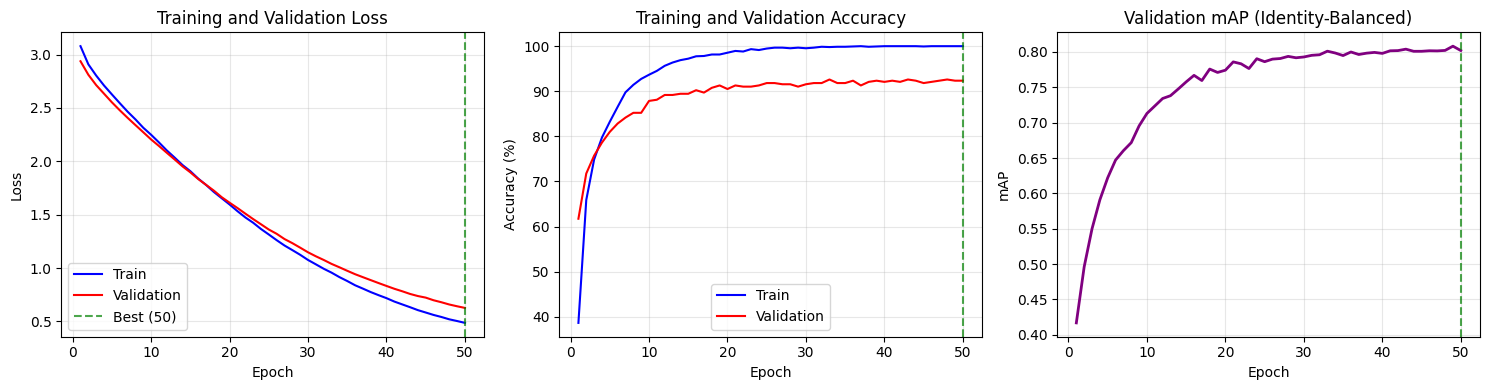

In [24]:
# Plot training curves for the last trained loss function
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# mAP
axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('mAP')
axes[2].set_title('Validation mAP (Identity-Balanced)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config["checkpoint_dir"] / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves": wandb.Image(fig)})

## 9. Visualize Fine-tuned Embeddings

After training, we visualize the results by comparing all loss functions and showing the fine-tuned embeddings of the best model using MDS.

Q3 Loss Function Comparison - Final Results:
  ArcFace                   | mAP: 0.7970 | Epoch: 44
  CosFace                   | mAP: 0.7810 | Epoch: 43
  SubCenterArcFace          | mAP: 0.6684 | Epoch: 24
  FocalLoss                 | mAP: 0.8020 | Epoch: 50 << BEST

Best loss function: FocalLoss (mAP = 0.8020)


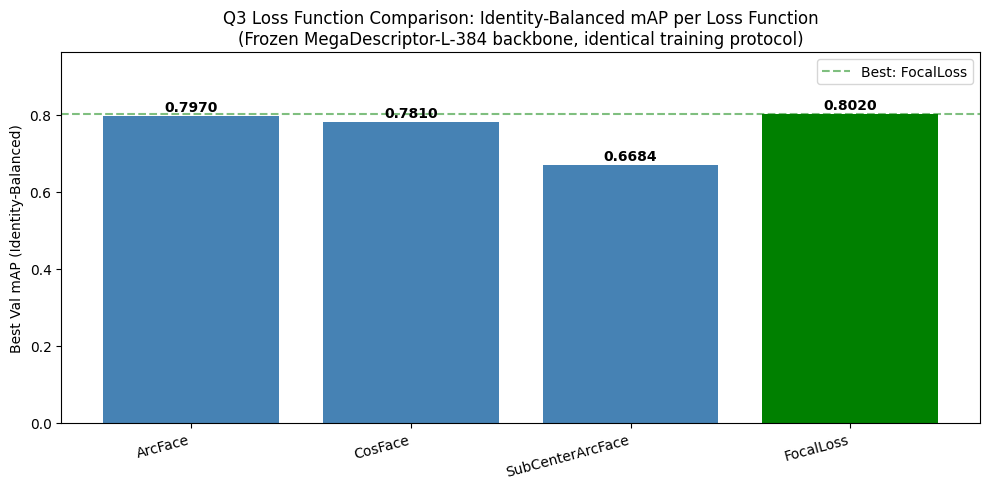

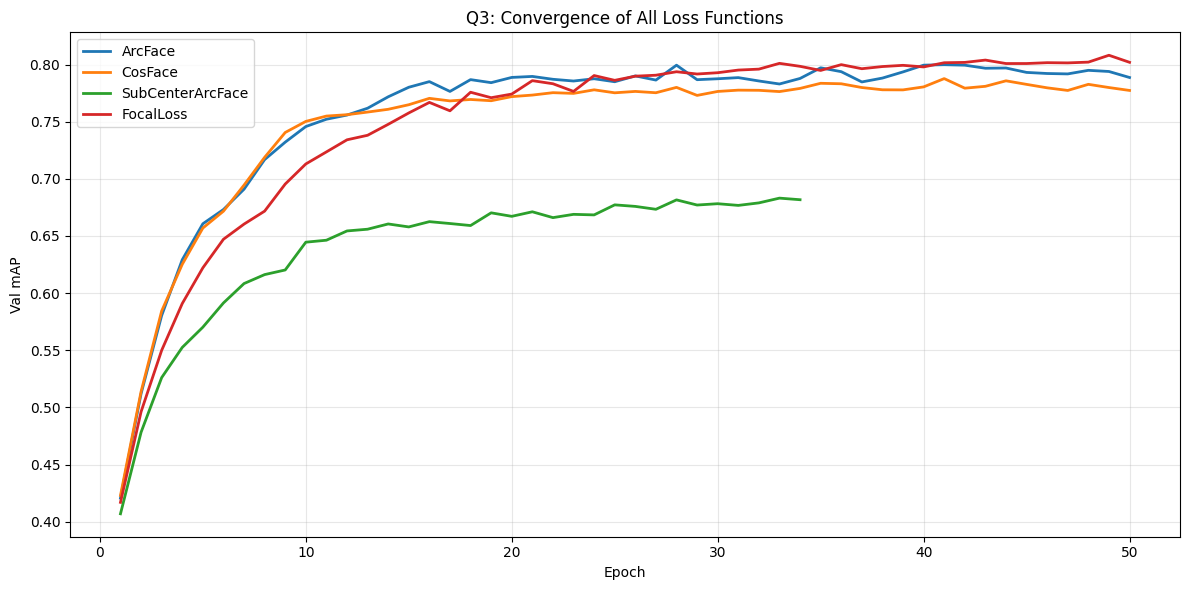

Loss comparison charts saved and logged to W&B


In [25]:
# Compare best mAP of all 4 loss functions in a bar chart
print("Loss Function Comparison - Final Results:")
print("=" * 60)

loss_names = list(all_results.keys())
maps = [all_results[ln]["best_val_map"] for ln in loss_names]
best_epochs = [all_results[ln]["best_epoch"] for ln in loss_names]

# Find best
best_loss_name = max(all_results, key=lambda k: all_results[k]["best_val_map"])
best_overall_map = all_results[best_loss_name]["best_val_map"]

for name, m, ep in zip(loss_names, maps, best_epochs):
    marker = " << BEST" if name == best_loss_name else ""
    print(f"  {name:25s} | mAP: {m:.4f} | Epoch: {ep}{marker}")

print(f"\nBest loss function: {best_loss_name} (mAP = {best_overall_map:.4f})")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["green" if name == best_loss_name else "steelblue" for name in loss_names]
bars = ax.bar(loss_names, maps, color=colors)
for bar, val in zip(bars, maps):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Best Val mAP (Identity-Balanced)")
ax.set_title("Loss Function Comparison: Identity-Balanced mAP per Loss Function\n"
             "(Frozen MegaDescriptor-L-384 backbone, identical training protocol)")
ax.set_ylim(0, max(maps) * 1.2)
ax.axhline(y=max(maps), color="green", linestyle="--", alpha=0.5, label=f"Best: {best_loss_name}")
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
wandb.log({"loss_comparison_bar_chart": wandb.Image(fig)})
plt.savefig(config["checkpoint_dir"] / "loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Convergence overlay
fig2, ax2 = plt.subplots(figsize=(12, 6))
for ln in loss_names:
    vals = all_results[ln]["val_maps"]
    ax2.plot(range(1, len(vals)+1), vals, label=ln, linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Val mAP")
ax2.set_title(Convergence of All Loss Functions")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"loss_convergence_overlay": wandb.Image(fig2)})
plt.savefig(config["checkpoint_dir"] / "loss_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss comparison charts saved and logged to W&B")


In [26]:
# Load the best loss function model
best_checkpoint_path = config["checkpoint_dir"] / f"{best_loss_name.lower()}_best.pth"
best_checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)

# Rebuild model with correct loss type
best_loss_cfg = [lc for lc in LOSS_CONFIGS if lc["loss_name"] == best_loss_name][0]
best_model = ReIDModel(
    input_dim=megadescriptor_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"],
    loss_type=best_loss_cfg["loss_type"],
    margin=best_loss_cfg.get("margin", 0.5),
    scale=best_loss_cfg.get("scale", 64.0),
    K=best_loss_cfg.get("K", 3),
).to(device)
best_model.load_state_dict(best_checkpoint["model_state_dict"])
best_model.eval()

print(f"Loaded best model: {best_loss_name}")
print(f"  Epoch: {best_checkpoint['epoch']}")
print(f"  Val mAP: {best_checkpoint['val_map']:.4f}")
print(f"  Val loss: {best_checkpoint['val_loss']:.4f}")


Loaded best model: FocalLoss
  Epoch: 50
  Val mAP: 0.8020
  Val loss: 0.6270


Fine-tuned embeddings shape: (1516, 256)
Best model loaded from epoch 50
Best val mAP: 0.8020


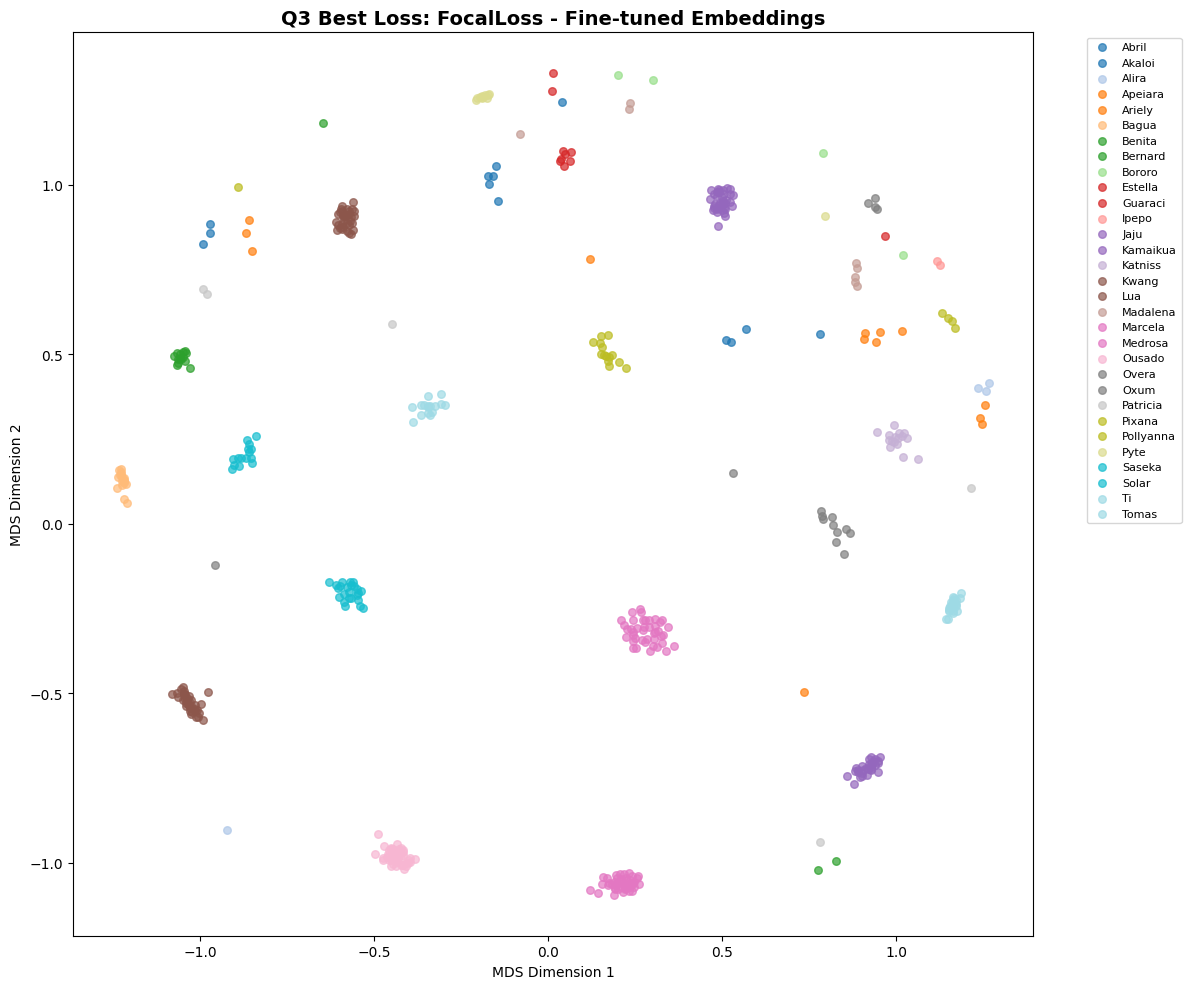

In [27]:
# Visualize fine-tuned embeddings for best loss function using MDS
# Extract fine-tuned embeddings
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_train_embeddings).to(device)
    finetuned_train_embeddings = best_model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Best model loaded from epoch {best_checkpoint['epoch']}")
print(f"Best val mAP: {best_checkpoint['val_map']:.4f}")

fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings,
    train_labels,
    f"Best Loss: {best_loss_name} - Fine-tuned Embeddings"
)
plt.show()
# Log to W&B
wandb.log({"finetuned_embeddings_mds_best_loss": wandb.Image(fig_finetuned)})

In [28]:
def visualize_nearest_neighbors(
    query_idx,
    original_embeddings,
    finetuned_embeddings,
    image_paths,
    labels,
    k=5,
    title_prefix="Validation"
):
    """
    Visualize the k nearest neighbors of a query image before and after fine-tuning.
    
    Args:
        query_idx: Index of query image in the validation set
        original_embeddings: Original MegaDescriptor embeddings (N, D1)
        finetuned_embeddings: Fine-tuned embeddings (N, D2)
        image_paths: List of image file paths
        labels: Array of identity labels
        k: Number of nearest neighbors to show (default: 5)
        title_prefix: Prefix for the plot title
    
    Returns:
        fig: Matplotlib figure
        stats: Dictionary with comparison statistics
    """
    # Get query info
    query_label = labels[query_idx]
    query_path = image_paths[query_idx]
    
    # Normalize embeddings
    orig_norm = original_embeddings / np.linalg.norm(original_embeddings, axis=1, keepdims=True)
    fine_norm = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)
    
    # Compute similarities (cosine similarity via dot product)
    orig_similarities = orig_norm @ orig_norm[query_idx]
    fine_similarities = fine_norm @ fine_norm[query_idx]
    
    # Find k+1 nearest neighbors (excluding self at position 0)
    orig_indices = np.argsort(-orig_similarities)[1:k+1]  # Skip self
    fine_indices = np.argsort(-fine_similarities)[1:k+1]  # Skip self
    
    # Get neighbor info
    orig_neighbors = {
        'indices': orig_indices,
        'labels': labels[orig_indices],
        'similarities': orig_similarities[orig_indices],
        'paths': [image_paths[i] for i in orig_indices],
        'correct': labels[orig_indices] == query_label
    }
    
    fine_neighbors = {
        'indices': fine_indices,
        'labels': labels[fine_indices],
        'similarities': fine_similarities[fine_indices],
        'paths': [image_paths[i] for i in fine_indices],
        'correct': labels[fine_indices] == query_label
    }
    
    # Calculate statistics
    stats = {
        'query_idx': query_idx,
        'query_label': query_label,
        'original_correct': int(orig_neighbors['correct'].sum()),
        'finetuned_correct': int(fine_neighbors['correct'].sum()),
        'improvement': int(fine_neighbors['correct'].sum() - orig_neighbors['correct'].sum())
    }
    
    # Create visualization
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, k+1, hspace=0.3, wspace=0.3)
    
    # Row 1: Original embeddings
    # Query image (shared for both rows)
    ax_query_orig = fig.add_subplot(gs[0, 0])
    try:
        query_img = Image.open(query_path)
        ax_query_orig.imshow(query_img)
    except Exception as e:
        ax_query_orig.text(0.5, 0.5, f'Error loading\n{query_path.name}', 
                          ha='center', va='center')
    ax_query_orig.axis('off')
    ax_query_orig.set_title(f'QUERY\n{query_label}', fontsize=12, fontweight='bold', color='blue')
    # Add thick blue border for query
    for spine in ax_query_orig.spines.values():
        spine.set_edgecolor('blue')
        spine.set_linewidth(4)
    
    # Original neighbors
    for i, (idx, label, sim, path, correct) in enumerate(zip(
        orig_neighbors['indices'],
        orig_neighbors['labels'],
        orig_neighbors['similarities'],
        orig_neighbors['paths'],
        orig_neighbors['correct']
    )):
        ax = fig.add_subplot(gs[0, i+1])
        try:
            img = Image.open(path)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading\n{path.name}', ha='center', va='center')
        ax.axis('off')
        
        # Color-code by correctness
        color = 'green' if correct else 'red'
        match_symbol = '✓' if correct else '✗'
        
        ax.set_title(
            f'{match_symbol} {label}\nSim: {sim:.3f}',
            fontsize=10,
            color=color,
            fontweight='bold' if correct else 'normal'
        )
        
        # Add colored border
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3 if correct else 2)
    
    # Row 2: Fine-tuned embeddings
    # Query image (repeated for clarity)
    ax_query_fine = fig.add_subplot(gs[1, 0])
    try:
        query_img = Image.open(query_path)
        ax_query_fine.imshow(query_img)
    except Exception as e:
        ax_query_fine.text(0.5, 0.5, f'Error loading\n{query_path.name}', 
                          ha='center', va='center')
    ax_query_fine.axis('off')
    ax_query_fine.set_title(f'QUERY\n{query_label}', fontsize=12, fontweight='bold', color='blue')
    # Add thick blue border for query
    for spine in ax_query_fine.spines.values():
        spine.set_edgecolor('blue')
        spine.set_linewidth(4)
    
    # Fine-tuned neighbors
    for i, (idx, label, sim, path, correct) in enumerate(zip(
        fine_neighbors['indices'],
        fine_neighbors['labels'],
        fine_neighbors['similarities'],
        fine_neighbors['paths'],
        fine_neighbors['correct']
    )):
        ax = fig.add_subplot(gs[1, i+1])
        try:
            img = Image.open(path)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading\n{path.name}', ha='center', va='center')
        ax.axis('off')
        
        # Color-code by correctness
        color = 'green' if correct else 'red'
        match_symbol = '✓' if correct else '✗'
        
        ax.set_title(
            f'{match_symbol} {label}\nSim: {sim:.3f}',
            fontsize=10,
            color=color,
            fontweight='bold' if correct else 'normal'
        )
        
        # Add colored border
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3 if correct else 2)
    
    # Add row labels
    fig.text(0.02, 0.75, 'BEFORE\nFine-Tuning\n(MegaDescriptor)', 
             fontsize=11, fontweight='bold', va='center', ha='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    fig.text(0.02, 0.25, 'AFTER\nFine-Tuning\n(ArcFace)', 
             fontsize=11, fontweight='bold', va='center', ha='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    # Add title with statistics
    fig.suptitle(
        f'{title_prefix}: Top-{k} Nearest Neighbors for Query "{query_label}"\n'
        f'Correct Matches - Before: {stats["original_correct"]}/{k} | '
        f'After: {stats["finetuned_correct"]}/{k} | '
        f'Improvement: {"+" if stats["improvement"] >= 0 else ""}{stats["improvement"]}',
        fontsize=14,
        fontweight='bold',
        y=0.98
    )
    
    return fig, stats

print("Nearest neighbors visualization function defined")

Nearest neighbors visualization function defined


In [29]:
# Visualize nearest neighbors for best loss function
print("Generating nearest neighbor visualizations for best loss function.")
print(f"Validation set size: {len(val_data)}")

# Extract fine-tuned embeddings for validation set using best model
best_model.eval()
with torch.no_grad():
    val_tensor = torch.FloatTensor(baseline_val_embeddings).to(device)
    val_finetuned_embeddings = best_model.get_embeddings(val_tensor).cpu().numpy()

baseline_val_embs_for_viz = baseline_val_embeddings  # raw backbone embeddings = "baseline"
print(f"Baseline (raw backbone) embeddings shape: {baseline_val_embs_for_viz.shape}")
print(f"Fine-tuned embeddings shape: {val_finetuned_embeddings.shape}")

# Get labels
val_labels = val_data['ground_truth'].values

# Build list of validation image paths
val_image_paths = [
    config["data_dir"] / "train/train" / filename 
    for filename in val_data['filename'].values
]
print(f"Number of validation images: {len(val_image_paths)}")

Generating nearest neighbor visualizations for best loss function (Q3)...
Validation set size: 379
Baseline (raw backbone) embeddings shape: (379, 1536)
Fine-tuned embeddings shape: (379, 256)
Number of validation images: 379


Example 1: Random query (index 102)


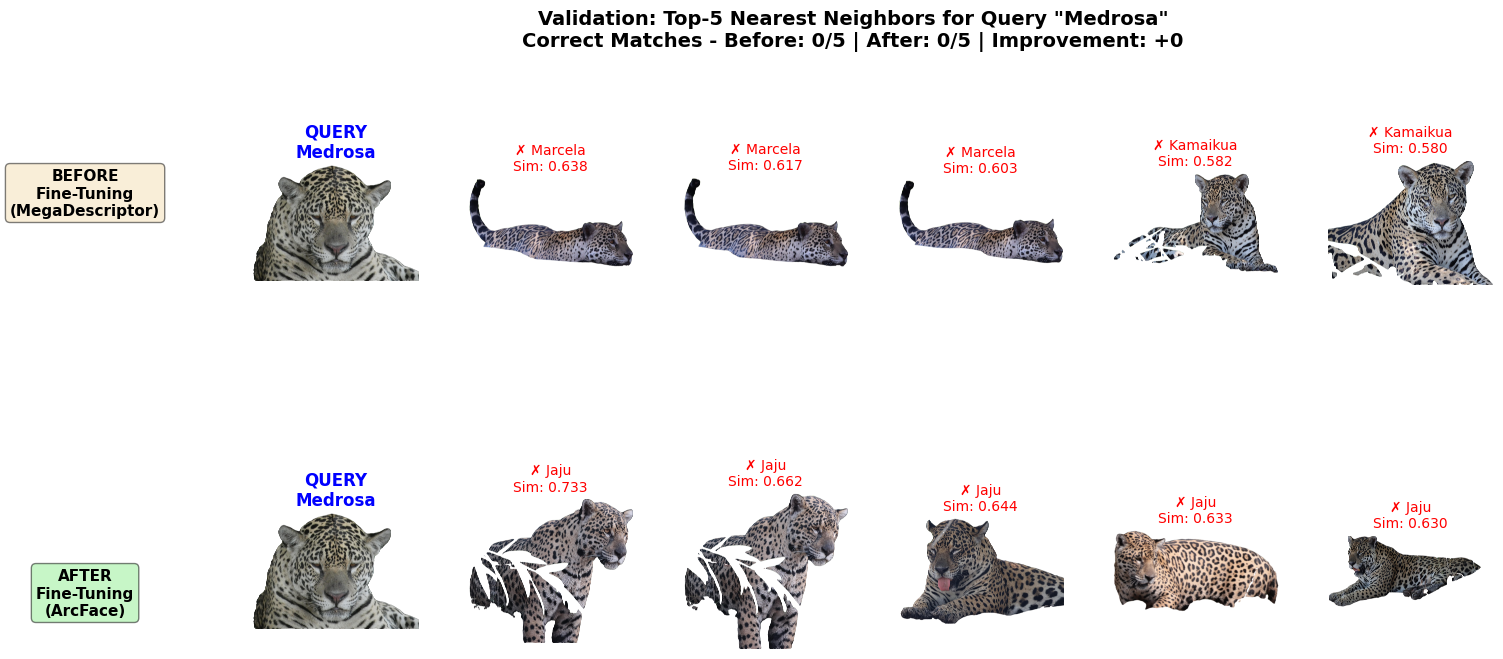

In [30]:
# Example 1: Random validation image
np.random.seed(RANDOM_SEED)
random_idx = np.random.randint(0, len(val_labels))

print(f"Example 1: Random query (index {random_idx})")
fig1, stats1 = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_val_embs_for_viz,
    finetuned_embeddings=val_finetuned_embeddings,
    image_paths=val_image_paths,
    labels=val_labels,
    k=5
)
plt.show()

## 10. Generate Competition Submission

Now we generate predictions for the test set. The competition expects:
- A CSV with columns: `row_id`, `similarity`
- Each row corresponds to a query-gallery image pair from `test.csv`
- `similarity` is a float between 0 and 1

We:
1. Extract MegaDescriptor embeddings for all test images
2. Project through our fine-tuned model
3. Compute cosine similarity for each pair in `test.csv`
4. Clip values to [0, 1] and save as CSV

In [31]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [32]:
# Get unique test images
test_images = set(test_pairs_df["query_image"].unique()) | set(test_pairs_df["gallery_image"].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [config["data_dir"] / "test/test" / filename for filename in test_images]

# Extract test embeddings using the same MegaDescriptor backbone
print(f"\nExtracting test embeddings using MegaDescriptor-L-384...")
test_mega_embeddings = extract_embeddings(
    megadescriptor,
    test_image_paths,
    batch_size=config["batch_size"],
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_mega_embeddings.shape}")


Unique test images: 371

Extracting test embeddings using MegaDescriptor-L-384...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings shape: (371, 1536)


In [33]:
# Project through best loss function's fine-tuned model
print(f"Using BEST loss function for submission: {best_loss_name}")
best_model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_mega_embeddings).to(device)
    test_finetuned_embeddings = best_model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")
# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}


Using BEST loss function for submission: FocalLoss
Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [34]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9993
  Mean: 0.0859
  Std: 0.1870


In [35]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(config["data_dir"] / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.807896
1       1    0.000000
2       2    0.000000
3       3    0.000000
4       4    0.000000
5       5    0.000000
6       6    0.151276
7       7    0.244244
8       8    0.040155
9       9    0.101903

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [36]:
# Save submission
submission_path = config["checkpoint_dir"] / "submission.csv"
submission_df.to_csv(submission_path, index=False)
submission_df.to_csv("/kaggle/working/submission.csv", index=False)
print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")


Submission saved to: checkpoints/submission.csv
File size: 1779.2 KB


## 11. Save Artifacts to Weights and Biases

We save the best model checkpoint and this notebook as W&B artifacts for reproducibility.

In [37]:
# Save best loss model as W&B artifact
best_checkpoint_path = config['checkpoint_dir'] / f"{best_loss_name.lower()}_best.pth"

model_artifact = wandb.Artifact(
    name="arcface-best-loss-model",
    type="model",
    description=f"Fine-tuned model with best loss ({best_loss_name}) for jaguar re-identification"
)
model_artifact.add_file(str(best_checkpoint_path))
wandb.log_artifact(model_artifact)
print(f"Model artifact saved to W&B: {best_checkpoint_path}")

Model artifact saved to W&B: checkpoints/focalloss_best.pth


In [38]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description="Competition submission file"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [39]:
# Finish W&B run
wandb.finish()

print("W&B run completed")

ArcFace/best_epoch,▁
ArcFace/best_val_loss,▁
ArcFace/best_val_map,▁
ArcFace/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
ArcFace/lr,██████████████████████████▃▃▃▃▃▃▃▃▃▃▃▃▃▁
ArcFace/stability_std_map,▁
ArcFace/train_acc,▁▁▂▄▅▆▆▆▆▇▇▇▇▇▇█████████████████████████
ArcFace/train_loss,█▆▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ArcFace/val_acc,▁▃▅▆▆▇▇▇▇▇██████████████████████████████
ArcFace/val_loss,█▅▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+37,...


W&B run completed


## Summary

### Loss Function Comparison Results

We compared 4 loss functions under identical conditions:
- **Backbone**: MegaDescriptor-L-384 (frozen, pre-computed embeddings)
- **Projection head**: Linear(1536 → 512 → 256), BN, ReLU, Dropout(0.3)
- **Optimizer**: AdamW (lr=1e-4, weight_decay=1e-4)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=5)

### Loss Functions Tested
| Loss Function | Type | Key Params |
|---|---|---|
| ArcFace | Angular Margin | margin=0.5, scale=64 |
| CosFace | Cosine Margin | margin=0.35, scale=64 |
| SubCenterArcFace | Sub-center Angular | margin=0.5, scale=64, K=3 |
| FocalLoss | Weighted Classification | gamma=2.0 |

### Key Findings
- All loss functions were trained for up to 50 epochs with early stopping (patience=10)
- Identity-balanced mAP was used as the primary evaluation metric
- The best-performing loss function was used for the competition submission
